In [18]:
# For the installation of OpenAI Gym use the following command in anaconda prompt
# conda install -c conda-forge gym

In [19]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import animation
import random
from collections import namedtuple, deque

In [20]:
from IPython.display import Image # For displaying images in colab jupyter cell

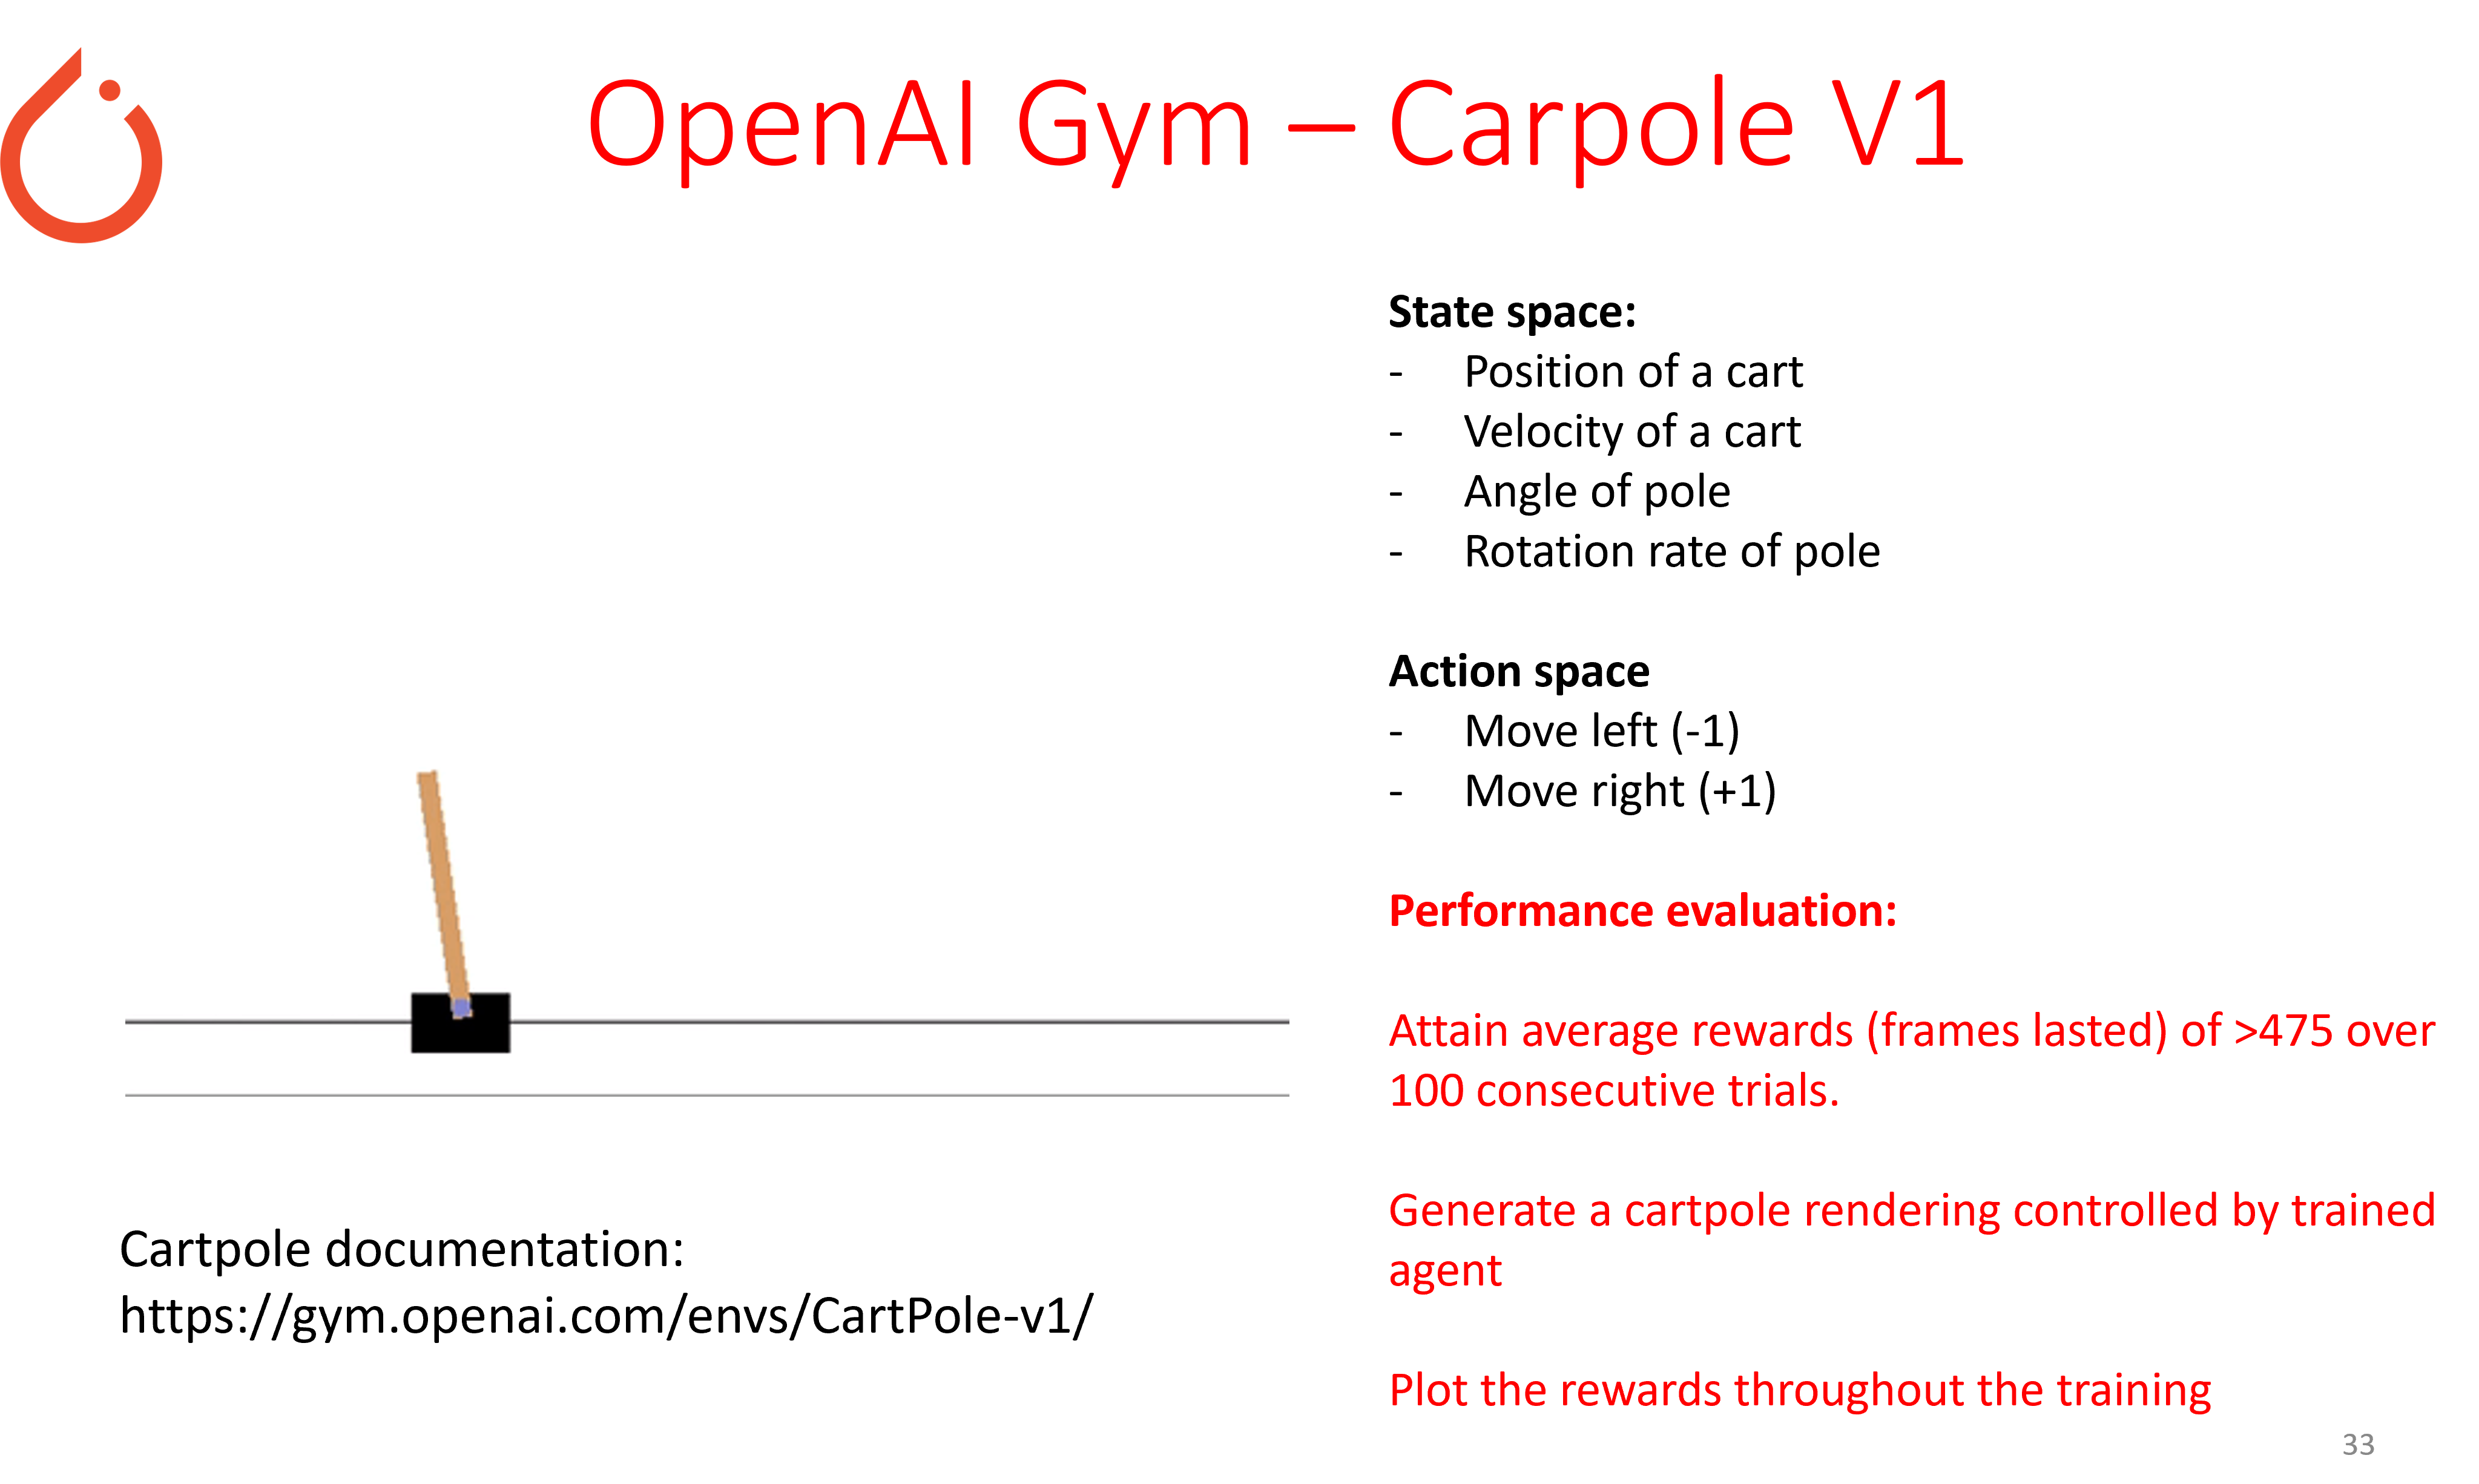

In [21]:
Image('lab9_exercise.png', width = 1000)

## Import cartpole environment from OpenAI Gym

In [22]:
env = gym.make('CartPole-v1', render_mode='rgb_array')
env.reset(seed=1)
torch.manual_seed(1)

## Define your Deep RL Architecture

In [23]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Running on device: {device}")

Running on device: mps


In [24]:
# YOUR DEEP RL ARCHITECTURE
class Q_network(nn.Module):

    def __init__(self, state_size,action_size, seed, fc1_unit,
                 fc2_unit):

        super(Q_network, self).__init__() 
        self.seed = torch.manual_seed(seed)
        self.fc1= nn.Linear(state_size,fc1_unit)
        self.fc2 = nn.Linear(fc1_unit,fc2_unit)
        self.fc3 = nn.Linear(fc2_unit,action_size)
        
    def forward(self,x):

        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        return self.fc3(x)

In [25]:
class ExperienceRelay:
    def __init__(self, action_size, buffer_size, batch_size, seed):
        self.action_size = action_size
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", 
                                     field_names=["state", "action", "reward", "next_state", "done"])
        self.seed = random.seed(seed)
    
    def add(self, state, action, reward, next_state, done):
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)
    
    def sample(self):
        experiences = random.sample(self.memory, k=self.batch_size)
        
        states = torch.from_numpy(np.vstack([e.state for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).long().to(device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float().to(device)
        
        return (states, actions, rewards, next_states, dones)
    
    def __len__(self):
        return len(self.memory)

In [26]:
class Agent():
    
    def __init__(self, 
                 state_size: int, 
                 action_size: int, 
                 seed: int, 
                 LR: float, 
                 BATCH_SIZE: int, 
                 GAMMA: float, 
                 BUFFER_SIZE: int, 
                 UPDATE_EVERY: int, 
                 TAU: float):
        
        self.state_size = state_size
        self.action_size = action_size
        self.seed = random.seed(seed)
        self.GAMMA = GAMMA
        self.BATCH_SIZE = BATCH_SIZE
        self.UPDATE_EVERY = UPDATE_EVERY
        self.TAU = TAU
        
        self.qnetwork_policy = Q_network(state_size, action_size, seed, 128, 128).to(device)
        self.qnetwork_target = Q_network(state_size, action_size, seed, 128, 128).to(device)
        self.qnetwork_target.load_state_dict(self.qnetwork_policy.state_dict()) 
        self.qnetwork_target.eval() 
        
        self.optimizer = torch.optim.Adam(self.qnetwork_policy.parameters(),lr=LR)
        
        self.memory = ExperienceRelay(action_size, BUFFER_SIZE,BATCH_SIZE, seed)
        self.t_step = 0
        
    def step(self, state, action, reward, next_state, done):
        self.memory.add(state, action, reward, next_state, done)

        self.t_step = (self.t_step+1)% self.UPDATE_EVERY
        if self.t_step == 0:

            if len(self.memory) > self.BATCH_SIZE:
                experience = self.memory.sample()
                self.learn(experience, self.GAMMA)
                
    def act(self, state, eps = 0.0):

        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        self.qnetwork_policy.eval()
        with torch.no_grad():
            action_values = self.qnetwork_policy(state)
        self.qnetwork_policy.train()

        if random.random() > eps:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.action_size))
            
    def learn(self, experiences, gamma):

        states, actions, rewards, next_state, dones = experiences
        criterion = torch.nn.MSELoss()
        self.qnetwork_policy.train()
        self.qnetwork_target.eval()
        predicted_targets = self.qnetwork_policy(states).gather(1,actions)
    
        with torch.no_grad():
            actions_next_policy = self.qnetwork_policy(next_state).argmax(1).unsqueeze(1)
            q_targets_next = self.qnetwork_target(next_state).gather(1, actions_next_policy)


        labels = rewards + (gamma * q_targets_next * (1 - dones))
        
        loss = criterion(predicted_targets,labels)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.soft_update(self.qnetwork_policy,self.qnetwork_target, self.TAU)
            
    def soft_update(self, local_model, target_model, tau):

        for target_param, local_param in zip(target_model.parameters(),
                                           local_model.parameters()):
            target_param.data.copy_(tau*local_param.data + (1-tau)*target_param.data)

## Define hyperparameters

In [27]:
# Hyperparameters

learning_rate = 1e-4    # learning rate
gamma = 0.99            # reward discount factor
buffer_size = int(3e3)  # replay buffer size
batchsize = 32          # minibatch size
tau =  1e-3             # for soft update of target parameters (0 -> hard update where target net == policy net)
update_every = 2        # how often to update the network

## Training loop

In [28]:
state_size = 4
action_size = 2

print(f'state size: {state_size}, action size: {action_size}') 

state size: 4, action size: 2


In [29]:
def train(episodes, 
          agent, 
          env,
          eps_start=1.0, 
          eps_end=0.01, 
          eps_decay=0.995,
          target_score=475.0, 
          consecutive_episodes_to_solve=100, 
          model_save_path='dqn_cartpole_checkpoint.pth'):
    scores = []
    scores_window = deque(maxlen=consecutive_episodes_to_solve) 
    epsilon = eps_start 

    print(f"Training on {device}...") 

    for episode in range(1, episodes + 1):
        state, info = env.reset()
        episode_score = 0

        for t in range(1000):
            action = agent.act(state=state, eps=epsilon) 

            env.render() 

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.step(state, action, reward, next_state, done)

            state = next_state
            episode_score += reward

            if done:
                break
        
        scores_window.append(episode_score)
        scores.append(episode_score)
        
        epsilon = max(eps_end, eps_decay * epsilon) # Decay epsilon

        print(f'\rEpisode {episode}\tAverage Score (last {consecutive_episodes_to_solve}): {np.mean(scores_window):.2f}\tEpsilon: {epsilon:.3f}', end="")
        if episode % 100 == 0:
            print(f'\rEpisode {episode}\tAverage Score (last {consecutive_episodes_to_solve}): {np.mean(scores_window):.2f}\tEpsilon: {epsilon:.3f}')
        
        if len(scores_window) == consecutive_episodes_to_solve and np.mean(scores_window) >= target_score:
            print(f'\nEnvironment solved in {episode:d} episodes!\tAverage Score: {np.mean(scores_window):.2f}')
            if model_save_path:
                torch.save(agent.qnetwork_policy.state_dict(), model_save_path)
                print(f"Model saved to {model_save_path}")
            break
            
    return scores

## Train agent

In [30]:
agent = Agent(state_size=state_size, 
              action_size=action_size, 
              seed=1, 
              LR=learning_rate, 
              BATCH_SIZE=batchsize, 
              GAMMA=gamma, 
              BUFFER_SIZE=buffer_size, 
              UPDATE_EVERY=update_every, 
              TAU=tau)

scores = train(episodes=3000, agent=agent, env=env)

Training on mps...
Episode 100	Average Score (last 100): 16.23	Epsilon: 0.606
Episode 200	Average Score (last 100): 15.01	Epsilon: 0.367
Episode 300	Average Score (last 100): 14.74	Epsilon: 0.222
Episode 400	Average Score (last 100): 28.22	Epsilon: 0.135
Episode 500	Average Score (last 100): 162.00	Epsilon: 0.082
Episode 600	Average Score (last 100): 186.95	Epsilon: 0.049
Episode 700	Average Score (last 100): 281.87	Epsilon: 0.030
Episode 800	Average Score (last 100): 178.08	Epsilon: 0.018
Episode 900	Average Score (last 100): 155.62	Epsilon: 0.011
Episode 1000	Average Score (last 100): 198.93	Epsilon: 0.010
Episode 1100	Average Score (last 100): 144.43	Epsilon: 0.010
Episode 1200	Average Score (last 100): 188.85	Epsilon: 0.010
Episode 1300	Average Score (last 100): 256.21	Epsilon: 0.010
Episode 1400	Average Score (last 100): 273.49	Epsilon: 0.010
Episode 1500	Average Score (last 100): 321.66	Epsilon: 0.010
Episode 1600	Average Score (last 100): 256.88	Epsilon: 0.010
Episode 1700	Avera

## Render the cartpole controlled by trained agent

In [31]:
def save_frames_as_mp4(frames, filename='gym_animation.mp4', fps=30): 
    """
    Saves a list of image frames as an MP4 video.

    Args:
        frames (list): A list of NumPy arrays, where each array is an image frame.
        filename (str): The desired output filename (e.g., 'animation.mp4').
        fps (int): Frames per second for the output video.
    """
    if not frames:
        print("No frames to save.")
        return

    if not filename.lower().endswith('.mp4'):
        filename += '.mp4'

    fig = plt.figure(figsize=(frames[0].shape[1] / 72.0, frames[0].shape[0] / 72.0), dpi=72)
    patch = plt.imshow(frames[0])
    plt.axis('off')

    def animate(i):
        patch.set_data(frames[i])
        return patch,

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=max(1, 1000//fps), blit=True)

    try:
        anim.save(filename, writer='ffmpeg', fps=fps)
        print(f"Animation saved to {filename}")
    except Exception as e:
        print(f"Error saving animation: {e}")
        print("Make sure ffmpeg is installed and in your system's PATH.")
    finally:
        plt.close(fig)

In [32]:
frames = []
state, info = env.reset(seed=1)

for t in range(1000):  
    action = agent.act(state, eps=0.0)

    frame = env.render()
    frames.append(frame)

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    state = next_state 

    if done:
        print(f"Episode finished after {t+1} timesteps")
        print(f"Final state: {state}")
        print(f"Terminated: {terminated}, Truncated: {truncated}")
        print(f"Info: {info}")
        break

env.close()
print(f"Number of frames collected for video: {len(frames)}")
if frames:
    save_frames_as_mp4(frames, filename='cartpole_agent_run.mp4', fps=30) 
else:
    print("No frames were recorded.")

Episode finished after 500 timesteps
Final state: [ 0.06282853  0.05056752  0.00387461 -0.07696214]
Terminated: False, Truncated: True
Info: {}
Number of frames collected for video: 500
Animation saved to cartpole_agent_run.mp4


## Plot the training progress

In [33]:
def plot_rewards(episode_scores, window_size=50, title="Training Rewards"):
    if not episode_scores:
        print("No scores to plot.")
        return

    plt.style.use('seaborn-v0_8-darkgrid') 
    plt.figure(figsize=(12, 6))

    plt.plot(episode_scores, label='Score per Episode', alpha=0.6, color='skyblue')

    if len(episode_scores) >= 1: 
        scores_series = pd.Series(episode_scores)
        running_avg = scores_series.rolling(window=window_size, min_periods=1).mean()
        plt.plot(running_avg, label=f'Running Average (Window: {window_size} episodes)', color='orangered', linewidth=2)

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend(loc='upper left') 
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

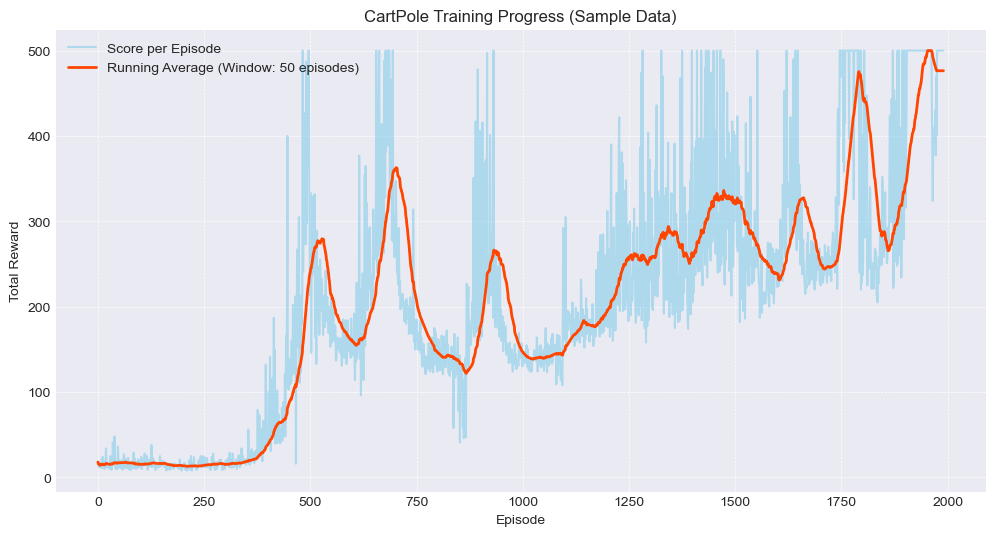

In [34]:
plot_rewards(scores, window_size=50, title="CartPole Training Progress (Sample Data)")